In [ ]:
import sys
from pathlib import Path
# Make the repo root importable regardless of CWD or machine: walk up from the
# working dir until we hit a repo marker, then put that dir on sys.path.
_start = Path.cwd()
_root = next((p for p in (_start, *_start.parents)
              if (p / ".git").exists() or (p / "setup.py").exists()), _start)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

# MetabTravLR quickstart

Train SpaceTravLR with **harreman metabolite transporter pairs** added as a modulator
group, then read the learned `beta_<export>@<import>` coefficients back out over labeled
gene sets to rank metabolites by effect. We analyze the coefficients directly — **no
perturbation**.

Edit the **Config** and **Gene sets** cells, then run top to bottom. Everything is written
under the dataset directory. On Savio, replace `fit(...)` with the `spawn_worker` cell.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import scanpy as sc

# SpaceTravLR package (src/) + our metab_processing helpers
_here = os.path.dirname(os.path.abspath('.'))
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))
sys.path.append(os.path.join(os.getcwd(), '..'))

from SpaceTravLR.spaceship import SpaceShip
from metab_processing.SpaceTravLR.metab_loader import load_metab_pairs
from metab_processing.SpaceTravLR import beta_analysis

In [ ]:
# from harreman_summary import select_tcell_metabolites
# select_tcell_metabolites(f'{dataset_dir}/easy_download')

Wrote 76 metabolites -> /global/scratch/users/fosterangus/MetabTravLR/Data/Xenium/Primary_Dermal_Melanoma/easy_download/harreman_outputs/metabolite_selection.yaml


PosixPath('/global/scratch/users/fosterangus/MetabTravLR/Data/Xenium/Primary_Dermal_Melanoma/easy_download/harreman_outputs/metabolite_selection.yaml')

## Config — data dir / dataset selection

Layout assumed: `DATA_DIR / DATASET / {adata.h5ad, easy_download/harreman_outputs/...}`.
Results are written to `DATA_DIR / DATASET / spacetravlr_output`.

In [2]:
from metab_processing.metab_travlr_config import PROJECT_DATA_DIR, DATA_DIR as METAB_DATA_DIR

DATA_DIR = PROJECT_DATA_DIR
DATASET  = 'Primary_Dermal_Melanoma'   # dataset folder under DATA_DIR

CELL_TYPE_SRC = 'leiden_scVI_res_0.5'   # adata.obs column to use as 'cell_type' (the harreman tier annotation)

dataset_dir    = f'{DATA_DIR}/{DATASET}'
adata_path     = f'{dataset_dir}/adata.h5ad'
harreman_dir   = f'{dataset_dir}/easy_download/harreman_outputs'
selection_yaml = f'{harreman_dir}/metabolite_selection.yaml'
outdir         = f'{dataset_dir}/spacetravlr_output'
betadata_dir   = f'{outdir}/betadata'

for p in (adata_path, selection_yaml):
    assert os.path.exists(p), f'missing: {p}'

## Gene sets

The target genes to train and the labels to score metabolites against. `focus_genes` (the
genes actually trained) is the union of all sets. **Edit these lists.** With exactly
`positive`/`negative` labels, the ranking uses `signed = positive − negative`.

In [3]:
GENE_SETS = {
    'positive': ['CD4', 'CD3E', 'IL2RA'],          # e.g. T-cell activity
    'negative': ['CTLA4', 'FOXP3', 'IL10', 'ENTPD1'],  # e.g. exhaustion
}

focus_genes = list(dict.fromkeys(g for genes in GENE_SETS.values() for g in genes))
print(f'{len(focus_genes)} focus genes:', focus_genes)

7 focus genes: ['CD4', 'CD3E', 'IL2RA', 'CTLA4', 'FOXP3', 'IL10', 'ENTPD1']


In [4]:
adata = sc.read_h5ad(adata_path)
adata.obs['cell_type'] = adata.obs[CELL_TYPE_SRC]
adata.layers['raw_count'] = adata.X
adata

AnnData object with n_obs × n_vars = 112551 × 5006
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', '_scvi_batch', '_scvi_labels', 'leiden_scVI_res_0.5', 'leiden_scVI_res_2.5', 'leiden_scVI_res_2', 'leiden_scVI_res_1.5', 'leiden_scVI_res_1', 'leiden_scVI_res_0.75', 'leiden_scVI_res_0.65', 'leiden_scVI_res_0.375', 'leiden_scVI_res_0.25', 'leiden_scVI_res_0.1', 'leiden_scVI_res_0.05', 'cd8', 'cd4', 't_cell', 'Tier1', 'Tier2', 'Tier3', 'Cytotoxic_CD8_score', 'Exhausted_CD8_score', 'Treg_score', 'sub_cluster_5_res_1', 'sub_cluster_5_res_0.75', 'sub_cluster_5_res_0.5', 'sub_cluster_5_res_0.37', 'sub_cluster_5_res_0.25', 'sub_cluster_5_res_0.15', 'sub_cluster_5_res_0.1', 'sub_cluster_5_res_0.05', 'sub_cluster_2_res_1', 'sub_cluster_2_res_0.75', 'sub_cluster_2_res_0

## Metabolite pairs from harreman

`metabolite_selection.yaml` → the deduped `metab_pairs` list (homotypic once, heterotypic
both orientations) filtered to genes in the panel. `selection` keeps the metabolite→pairs
grouping for the read-back.

In [5]:
metab_pairs, selection = load_metab_pairs(selection_yaml, var_names=adata.var_names)
print(f'{len(selection)} metabolites, {len(metab_pairs)} model pairs (both orientations, in-panel)')
metab_pairs[:8]

build_metab_pairs: dropped 0 of 144 metab_pairs (gene absent from var_names); kept 144
76 metabolites, 144 model pairs (both orientations, in-panel)


[('ABCB1', 'ABCB1'),
 ('SLC15A1', 'SLC15A1'),
 ('ABCA1', 'ABCA1'),
 ('ATP7A', 'ATP7A'),
 ('ATP7A', 'ATP7B'),
 ('ATP7B', 'ATP7A'),
 ('SLC16A4', 'SLC16A4'),
 ('SLC16A4', 'SLCO2B1')]

## Setup + train

COMMOT is skipped — harreman is our metabolite prior. Only `focus_genes` are trained.

In [12]:
spacetravlr = SpaceShip(
    name=DATASET.replace('/', '_'),
    outdir=outdir,
    genes=focus_genes,
)

In [13]:
spacetravlr.setup_(adata, overwrite=False, run_commot=False)
assert spacetravlr.is_everything_ok()

AssertionError: Launch script not found

In [14]:
# Local / single-process training. On Savio use the spawn_worker cell below instead.
spacetravlr.fit(metab_pairs=metab_pairs)

Fitting ENTPD1 with 1252 modulators
	83 Transcription Factors
	638 Ligand-Receptor Pairs
	387 TranscriptionFactor-Ligand Pairs
	0 Extra modulators
	144 Metabolite Pairs
0: 0.6581 | 0.6443
1: 0.9241 | 0.9091
2: 0.7012 | 0.7302
3: 0.9581 | 0.9423
4: 0.7945 | 0.7428
5: 0.9738 | 0.9645
6: 0.3118 | 0.3106
7: 0.9353 | 0.9154
8: 0.5697 | 0.5665
9: 0.9354 | 0.9287
10: 0.7432 | 0.7069
Deleted lock for CD3E after 3600 seconds
Fitting CD3E with 1055 modulators
	47 Transcription Factors
	640 Ligand-Receptor Pairs
	224 TranscriptionFactor-Ligand Pairs
	0 Extra modulators
	144 Metabolite Pairs
0: 0.5713 | 0.5446
1: 0.7856 | 0.7812
2: 0.7087 | 0.6882
3: 0.8170 | 0.7577
4: 0.6562 | 0.6228
5: 0.6864 | 0.6030
6: 0.2848 | 0.2846
7: 0.7183 | 0.6715
8: 0.6232 | 0.6219
9: 0.5927 | 0.5567
10: 0.6982 | 0.6222


In [ ]:
# --- Savio: run this cell (multiple times) to spawn parallel SLURM workers instead of fit() ---
# spacetravlr.focus_genes = focus_genes
# spacetravlr.spawn_worker(
#     account='fc_wagnerlabfca',
#     partition='savio4_gpu',
#     qos='a5k_gpu4_normal',
#     gres='gpu:A5000:1',
#     job_name='MetabTravLR',
#     cpus_per_task=4,
#     lifespan=0.5,
#     python_path='/global/home/users/fosterangus/.conda/envs/spacetravlr/bin/python',
#     metab_pairs=metab_pairs,   # if driving via a launch.py, pass metab_pairs to run_spacetravlr
# )

## Read the metabolite coefficients back out

For each tier (an `adata.obs` cell-type column), group cells by their label and take the
mean/std of every metabolite-pair beta. Written to
`easy_download/metabtravlr_outputs/<tier>/`.

In [6]:
TIERS = ['Tier1', 'Tier2', 'Tier3']
metab_outdir = f'{dataset_dir}/easy_download/metabtravlr_outputs'

# <tier>/gene_pairs.csv: mean/std per (gene, transporter pair, cell type)
gene_pairs = beta_analysis.write_gene_pairs(betadata_dir, adata.obs, TIERS, metab_outdir, genes=focus_genes)
gene_pairs['Tier1'].head()

,gene,export,import,pair,cell_type,mean,std,n
0,CD3E,ABCA1,ABCA1,ABCA1@ABCA1,T Cell,-5.787901e-06,4.158413e-06,9364
1,CD3E,ATP7A,ATP7A,ATP7A@ATP7A,T Cell,-4.871437e-07,3.004529e-07,9364
2,CD3E,SLC16A4,SLC16A4,SLC16A4@SLC16A4,T Cell,1.423516e-05,2.877189e-06,9364
3,CD3E,SLC16A4,SLCO2B1,SLC16A4@SLCO2B1,T Cell,-2.407356e-06,6.328670e-07,9364
4,CD3E,SLCO2B1,SLC16A4,SLCO2B1@SLC16A4,T Cell,3.395277e-06,8.616784e-07,9364


In [7]:
# <tier>/histograms.csv: distribution of those mean betas, per modulator group
# (metab / lr / ltf / tf). plot=True also writes histograms.png.
hists = beta_analysis.write_histograms(betadata_dir, adata.obs, TIERS, metab_outdir, genes=focus_genes, plot=True)
hists['Tier1'].head()

,group,left,right,count
0,lr,-0.008692,-0.008408,1
1,lr,-0.008408,-0.008123,0
2,lr,-0.008123,-0.007839,1
3,lr,-0.007839,-0.007554,0
4,lr,-0.007554,-0.007269,0


In [8]:
# Per-cell betas back onto the cells: adata.obsm['beta_<gene>'], names in adata.uns['beta_modulators']
beta_analysis.betas_to_adata(adata, betadata_dir, genes=focus_genes)
adata.obsm['beta_CD4'].shape, adata.uns['beta_modulators']['CD4'][:5]

((112551, 100),
 ['ABCA1@ABCA1',
  'ATP7A@ATP7A',
  'SLC16A4@SLCO2B1',
  'SLCO2B1@SLC16A4',
  'SLCO2B1@SLCO2B1'])

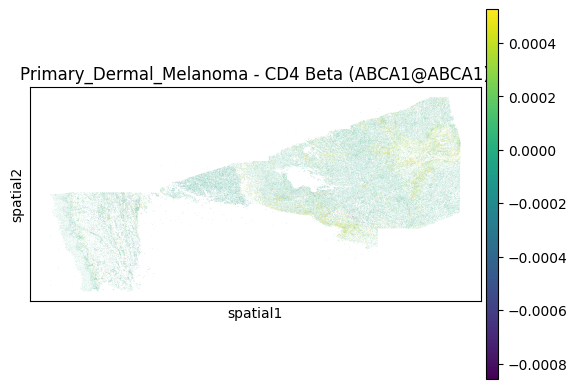

In [12]:
# 1. Find the index of the modulator you want to plot
modulator_name = 'ABCA1@ABCA1'
modulator_idx = adata.uns['beta_modulators']['CD4'].index(modulator_name)

# 2. Extract that specific column and assign it to a new column in adata.obs
adata.obs[f'beta_CD4_{modulator_name}'] = adata.obsm['beta_CD4'][:, modulator_idx]

# 3. Plot using the standard AnnData object
sc.pl.spatial(
    adata, 
    color=f'beta_CD4_{modulator_name}', 
    spot_size=5, 
    title=f'{DATASET} - CD4 Beta ({modulator_name})'
)

In [9]:
from Harreman.copy_easy_download import save_easy_downloads
save_easy_downloads()